# Week 3 Tarun Jindal Notebook


<a href="https://colab.research.google.com/github/tarunjindal787/Tarun_Jindal_JECRC_Foundation_CEI/blob/main/Week_3_Tarun_Jindal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")

## Dataset Loading

In this step, the dataset is loaded into Python using Pandas. The dataset contains different socio-economic indicators for various countries. These features will be used for clustering and prediction tasks.


In [2]:
df = pd.read_csv("/content/Country-data.csv")

df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


## Data Quality Check

This section checks whether the dataset contains missing values or duplicate records.

Because Clean data helps improve model performance and ensures reliable results.


In [52]:
print(df.shape)

print("Columns:")
print(df.columns)

print("Missing Values:")
print(df.isnull().sum())

print("Duplicate Values:")
print(df.duplicated().sum())

(167, 12)
Columns:
Index(['country', 'child_mort', 'exports', 'health', 'imports', 'income',
       'inflation', 'life_expec', 'total_fer', 'gdpp', 'Segment',
       'DBSCAN_Segment'],
      dtype='object')
Missing Values:
country           0
child_mort        0
exports           0
health            0
imports           0
income            0
inflation         0
life_expec        0
total_fer         0
gdpp              0
Segment           0
DBSCAN_Segment    0
dtype: int64
Duplicate Values:
0


## Data Understanding

Before building any machine learning model, it is important to understand the dataset. This step helps me to check the number of rows and columns, data types. and whatever that i have want.


In [4]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


## Correlation Analysis

The correlation heatmap helps me to understand the relationship between different features.

 Highly correlated features may provide similar information, while weakly correlated features may contribute unique insights.


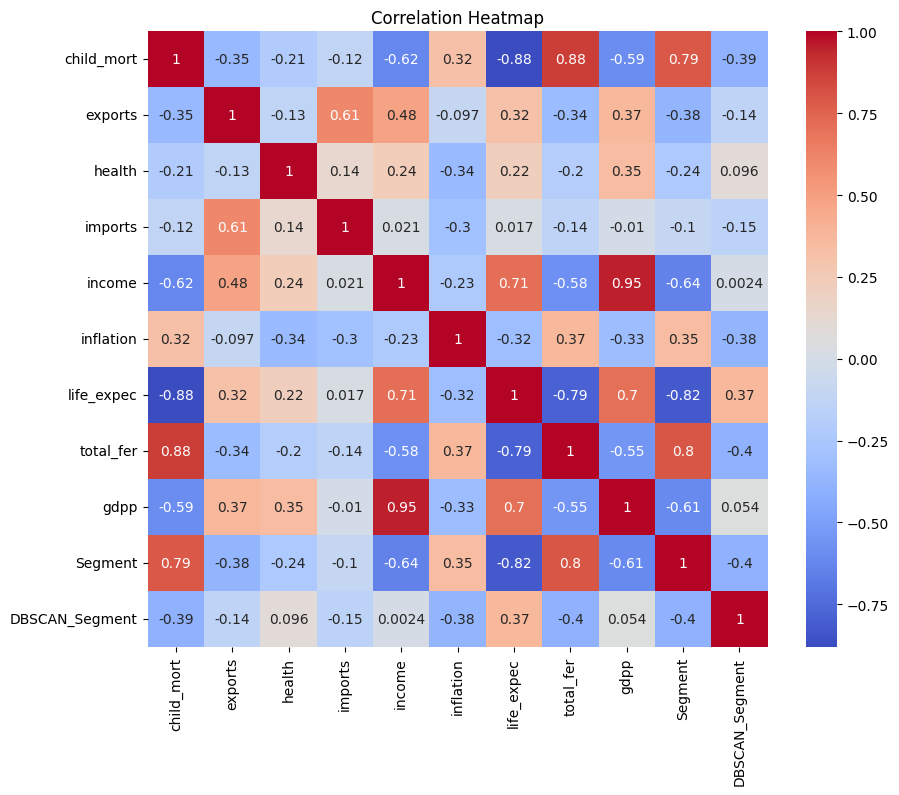

In [53]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.drop("country",axis=1).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

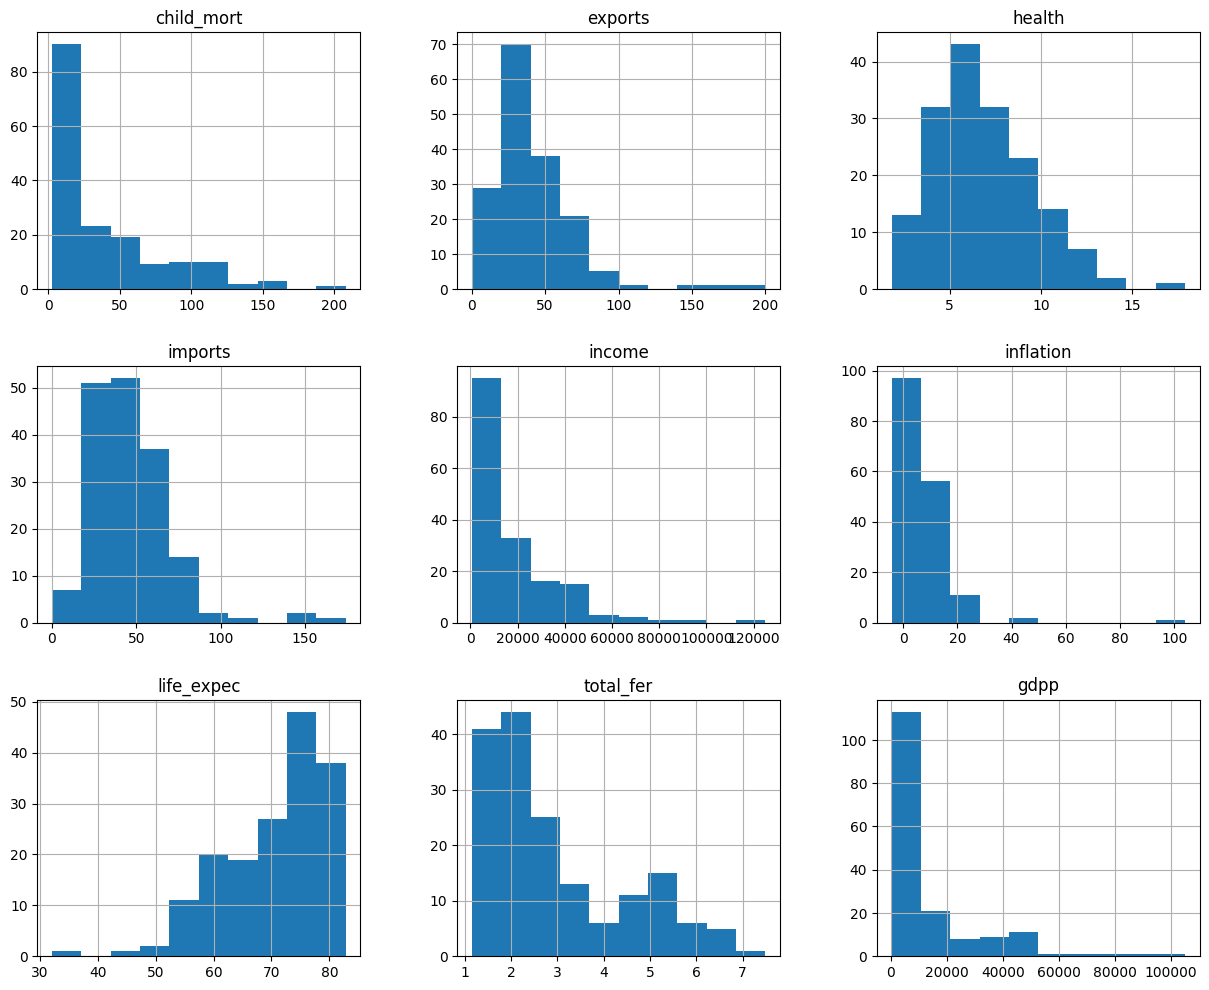

In [6]:
df.hist(figsize=(15,12))
plt.show()

## Outlier Detection

Boxplots help me to identify extreme values in the dataset.

 Outliers can affect clustering and machine learning models, so they need to be examined carefully.


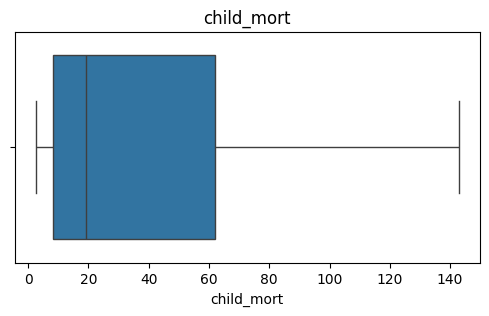

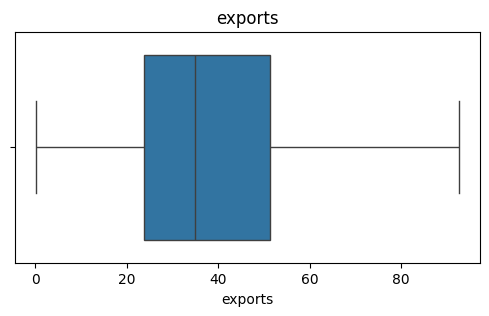

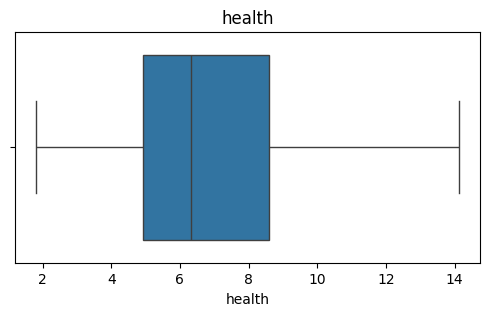

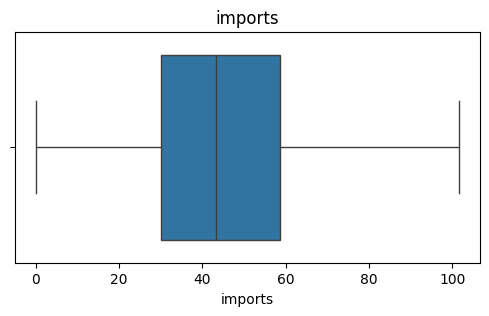

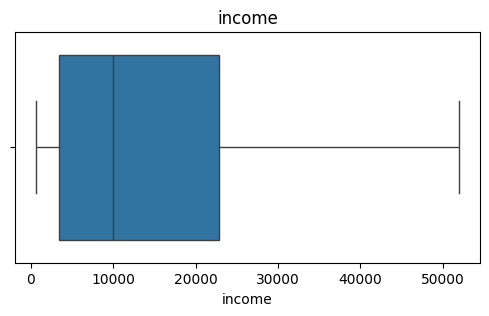

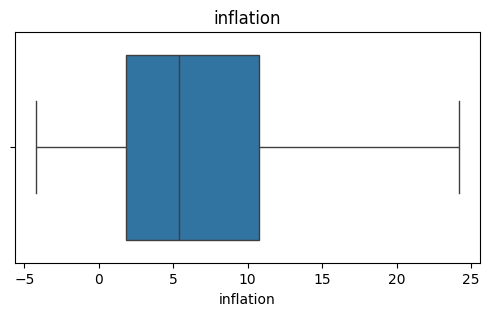

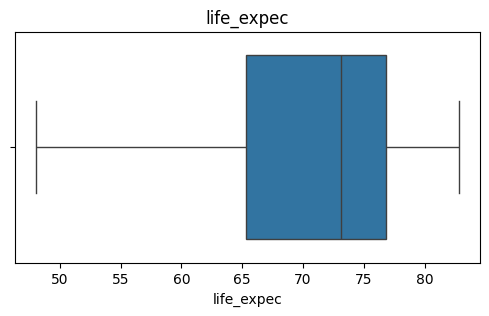

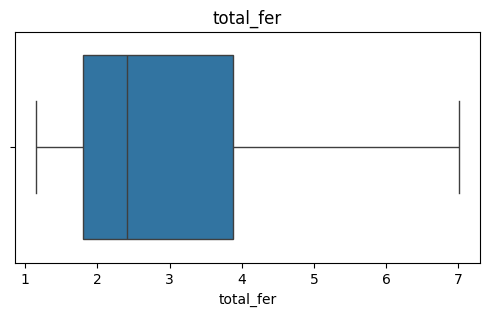

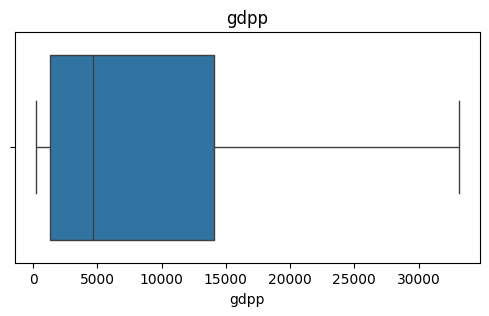

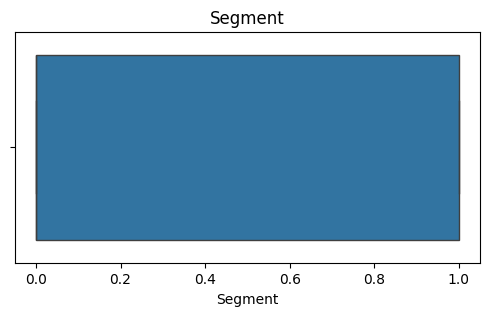

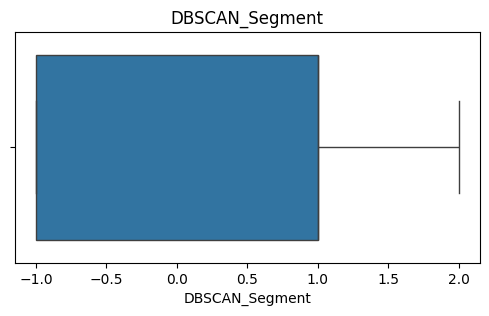

In [54]:
for col in df.columns[1:]:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [8]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

## Handling Outlier

Outliers are handled using the IQR method. Instead of removing records, extreme values are capped within acceptable limits to preserve important information while reducing their impact.


In [55]:
for col in numeric_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = np.clip(df[col], lower, upper)

## Feature Scaling

The dataset contains features with different ranges. Standardization is applied so that all features contribute equally during clustering and classification.


In [56]:

from sklearn.preprocessing import StandardScaler

X = df.drop('country',axis=1)

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

## Dimensionality Reduction using PCA

Principal Component Analysis (PCA) is used to reduce the number of dimensions while preserving most of the information in the dataset.

 This improves efficiency and reduces noise.


In [11]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.90)

X_pca = pca.fit_transform(X_scaled)

print("Original Shape:", X_scaled.shape)
print("PCA Shape:", X_pca.shape)

Original Shape: (167, 9)
PCA Shape: (167, 5)


## Customer Segmentation using K-Means

K-Means clustering is used to divide countries into groups with similar characteristics. The optimal number of clusters is selected using the Silhouette Score.

we can also use wcss elbow method

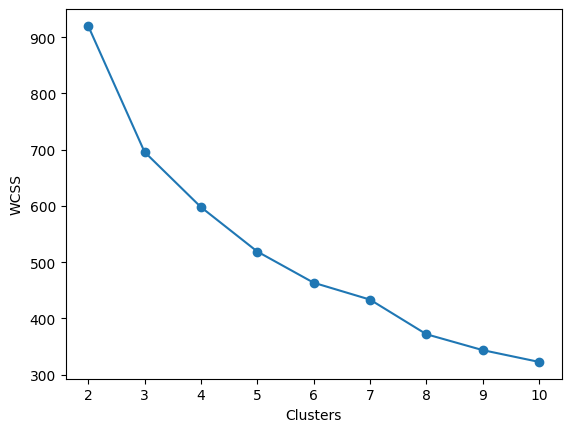

In [57]:
from sklearn.cluster import KMeans

wcss = []

for i in range(2,11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_pca)

    wcss.append(kmeans.inertia_)

plt.plot(range(2,11),wcss,marker='o')
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.show()

In [58]:
from sklearn.metrics import silhouette_score

scores = []

for i in range(2,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_pca)

    score = silhouette_score(X_pca,labels)

    scores.append(score)

best_k = np.argmax(scores)+2

print("Best K =",best_k)

Best K = 2


In [59]:
kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

df["Segment"] = kmeans.fit_predict(X_pca)

## Density-Based Clustering using DBSCAN

DBSCAN is applied as an alternative clustering technique. Unlike K-Means, it can identify noise points and clusters with irregular shapes.


In [15]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=1.2,
    min_samples=5
)

df["DBSCAN_Segment"] = dbscan.fit_predict(X_pca)

### Ensemble Learning: Random Forest & XGBoost
We will now train ensemble models to classify countries into these discovered clusters and identify the most important predictive features.

In [60]:
segment_profile = df.groupby("Segment").mean(numeric_only=True)

segment_profile

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,DBSCAN_Segment
Segment,,,,,,,,,,
0,12.171429,46.231378,7.320102,47.596939,24111.020408,5.105214,76.515306,1.938469,16236.020408,0.581633
1,73.953623,30.044913,6.043333,43.398057,4290.188406,9.848623,62.352899,4.374746,1993.246377,-0.173913


In [61]:
X_cls = df.drop(
    ['country',
     'Segment',
     'DBSCAN_Segment'],
    axis=1
)

y = df['Segment']

## Preparing Data for Classification

The dataset is divided into training and testing sets. The training set is used to build models,

 while the testing set is used to evaluate performance on unseen data.


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_cls,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

## Random Forest Classification

Random Forest is an ensemble learning algorithm that combines multiple decision trees. It is used to predict cluster labels and evaluate predictive performance.


In [39]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=150,
    max_depth=4,
    min_samples_split=15,
    min_samples_leaf=8,
    max_features='sqrt',
    random_state=42
)

rf.fit(X_train,y_train)

RandomForestClassifier(max_depth=4, min_samples_leaf=8, min_samples_split=15,
                       n_estimators=150, random_state=42)

## Random Forest Performance Evaluation

The model is evaluated using training accuracy, testing accuracy, confusion matrix, and classification report. These metrics help measure prediction quality and identify overfitting.


In [62]:
train_pred_rf = rf.predict(X_train)
test_pred_rf = rf.predict(X_test)
print("Random Forest Train Accuracy:", accuracy_score(y_train, train_pred_rf))
print("Random Forest Test Accuracy:", accuracy_score(y_test, test_pred_rf))

Random Forest Train Accuracy: 0.9774436090225563
Random Forest Test Accuracy: 0.8529411764705882


In [63]:
train_acc = accuracy_score(y_train,train_pred_rf)
test_acc = accuracy_score(y_test,test_pred_rf)

gap = train_acc - test_acc

print("Gap:",gap)

if gap > 0.10:
    print("Overfitting Detected")
elif train_acc < 0.70 and test_acc < 0.70:
    print("Underfitting Detected")
else:
    print("Model Generalizing Well")

Gap: 0.12450243255196813
Overfitting Detected


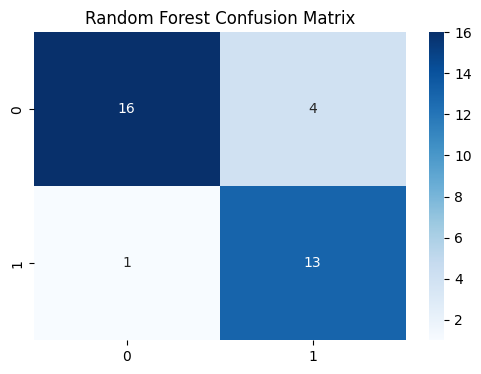

In [64]:
cm = confusion_matrix(y_test,test_pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Random Forest Confusion Matrix")
plt.show()

In [65]:
print(classification_report(y_test, test_pred_rf))

              precision    recall  f1-score   support

           0       0.94      0.80      0.86        20
           1       0.76      0.93      0.84        14

    accuracy                           0.85        34
   macro avg       0.85      0.86      0.85        34
weighted avg       0.87      0.85      0.85        34



## XGBoost Classification

XGBoost is a powerful boosting algorithm that builds trees sequentially to improve prediction accuracy. It is widely used in machine learning competitions and real-world applications.


In [44]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=1,
    reg_lambda=1,
    random_state=42,
    eval_metric='mlogloss'
)

xgb.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.03, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

## XGBoost Performance Evaluation

The performance of XGBoost is measured using accuracy, confusion matrix, and classification report. The results are compared with Random Forest to determine the better model.


In [66]:
pred_train_xgb = xgb.predict(X_train)
pred_test_xgb = xgb.predict(X_test)
print("XGBoost Train Accuracy:", accuracy_score(y_train, pred_train_xgb))
print("XGBoost Test Accuracy:", accuracy_score(y_test, pred_test_xgb))

XGBoost Train Accuracy: 0.9849624060150376
XGBoost Test Accuracy: 0.9117647058823529


In [67]:
train_acc = accuracy_score(y_train,pred_train_xgb)
test_acc = accuracy_score(y_test,pred_test_xgb)

print("Train Accuracy:",train_acc)
print("Test Accuracy :",test_acc)

gap = train_acc - test_acc

print("Gap:",gap)

if gap > 0.10:
    print("Overfitting Detected")
elif train_acc < 0.70 and test_acc < 0.70:
    print("Underfitting Detected")
else:
    print("Model Generalizing Well")

Train Accuracy: 0.9849624060150376
Test Accuracy : 0.9117647058823529
Gap: 0.07319770013268467
Model Generalizing Well


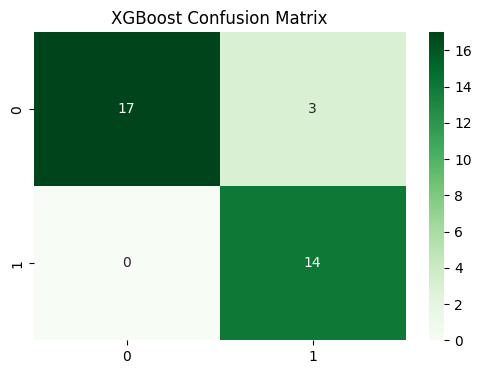

In [68]:
cm = confusion_matrix(y_test,pred_test_xgb)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("XGBoost Confusion Matrix")
plt.show()

In [69]:
print(classification_report(y_test,pred_test_xgb))

              precision    recall  f1-score   support

           0       1.00      0.85      0.92        20
           1       0.82      1.00      0.90        14

    accuracy                           0.91        34
   macro avg       0.91      0.93      0.91        34
weighted avg       0.93      0.91      0.91        34



## Cross Validation

Cross validation is performed to measure how well the model generalizes to unseen data. This provides a more reliable estimate of model performance.


In [49]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
rf_scores = cross_val_score(
    rf,
    X_cls,
    y,
    cv=cv,
    scoring='accuracy'
)

xgb_scores = cross_val_score(
    xgb,
    X_cls,
    y,
    cv=cv,
    scoring='accuracy'
)

print("RF Mean CV:", rf_scores.mean())
print("XGB Mean CV:", xgb_scores.mean())

RF Mean CV: 0.95222816399287
XGB Mean CV: 0.9581105169340465


## Feature Importance Analysis

Feature importance helps identify which variables contribute the most to predictions. These insights can be useful for decision-making and further analysis.


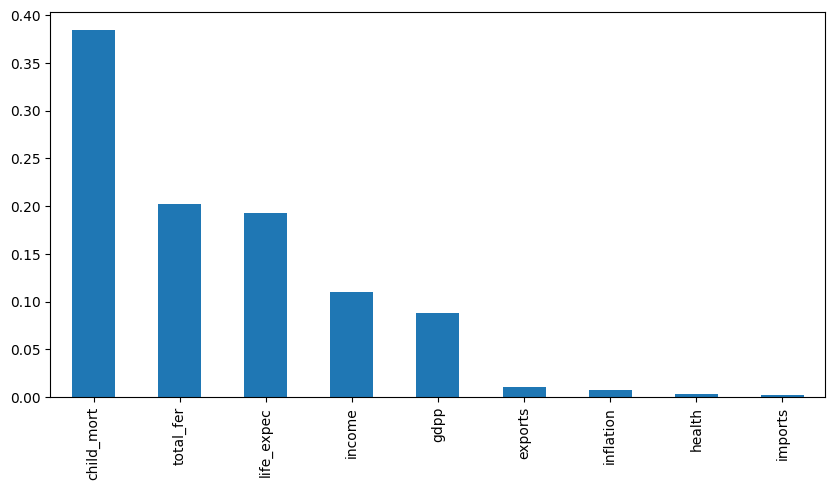

In [50]:
importance = pd.Series(
    rf.feature_importances_,
    index=X_cls.columns
)

importance.sort_values(
    ascending=False
).plot(
    kind='bar',
    figsize=(10,5)
)

plt.show()

In [51]:
importance.sort_values(ascending=False)

,0
child_mort,0.384251
total_fer,0.202414
life_expec,0.192913
income,0.109859
gdpp,0.087670
exports,0.011027
inflation,0.006923
health,0.003069
imports,0.001875


# Conclusion

In this project, different machine learning and clustering techniques were applied to analyze the country-level dataset. The data was first cleaned and prepared by handling outliers, scaling features, and reducing dimensions using PCA.

K-Means and DBSCAN were used to group countries with similar characteristics. These clusters helped in understanding different patterns present in the dataset. Random Forest and XGBoost models were then trained to predict these segments.

After evaluating both models, XGBoost performed better on the test data and showed better generalization ability. Cross-validation results also confirmed that the model is reliable and can perform well on unseen data.

Overall, this project demonstrates how clustering and classification techniques can be combined to generate meaningful insights and build an effective Customer Intelligence System.

